In [1]:
import sys, os
from pathlib import Path
from datetime import datetime

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))

In [3]:
import numpy as np
import pandas as pd
from src.get_data import load_data
from src.train.poisson_baseline.baseline_main import (
    fit_poisson_glm,
    fit_poisson_xgboost,
)
from src.train.poisson_nn.nn_main import (
    fit_poisson_nn,
    fit_poisson_nn_transfer_learning,
)
from src.train.training import run_experiment
from src.visualisation import (
    plot_training_curves,
    plot_ytrue_vs_ypred,
    compare_models_for_cell,
    compare_r2_across_cells,  # improved version with sort_by
    compare_models_pairwise_r2,
    journal_plot_pack,  # improved version
    plot_r2_comparison_boxplot,  # NEW — main report figure
    plot_r2_histogram,  # NEW — mirrors paper Fig 3E
    plot_covariate_trial,  # NEW — Figure 1 data overview
    COVARIATE_NAMES_REAL,  # NEW — covariate name constant
)
from src.train.poisson_nn.nn_models import CNNExtractor, RNNExtractor
from sklearn.preprocessing import StandardScaler

In [4]:
# Real data
X, Y, cell_ids, rec_ids = load_data("../resources/data/real/Temi_Data.mat")

In [5]:
X.shape, Y.shape, cell_ids.shape, rec_ids.shape

((14, 1657180), (1657180,), (1657180,), (1657180,))

In [6]:
np.unique(cell_ids).shape

(247,)

In [7]:
# ============================
# BATCH CONTROL (manual)
# ============================

CELLS_PER_BATCH = 25  # how many cells to include per run
BATCH_INDEX = 2  # manually change this: 0, 1, 2, ...

# Compute batches from the full set of cell IDs
unique_cells = np.unique(cell_ids)
batches = [
    unique_cells[i : i + CELLS_PER_BATCH]
    for i in range(0, len(unique_cells), CELLS_PER_BATCH)
]

# Select the batch you want to run
CURRENT_BATCH_CELLS = batches[BATCH_INDEX]

mask = np.isin(cell_ids, CURRENT_BATCH_CELLS)

X = X[:, mask]
Y = Y[mask]
cell_ids = cell_ids[mask]
rec_ids = rec_ids[mask]

In [8]:
BASE_MODEL_DIR = f"../resources/models/real/batch_{BATCH_INDEX}"
BASE_RESULTS_DIR = f"../resources/results/real/batch_{BATCH_INDEX}"
LOG_PATH = os.path.join(Path(BASE_RESULTS_DIR), f"batch_log_{BATCH_INDEX}.txt")

FORCE_EXPERIMENTS = False

In [9]:
def log_print(*args, **kwargs):
    """Print to console AND append to batch log file."""
    text = " ".join(str(a) for a in args)

    # Print to console
    print(text, **kwargs)

    # Append to log file
    with open(LOG_PATH, "a", encoding="utf-8") as f:
        f.write(text + "\n")

In [10]:
# Ensure the batch directory exists BEFORE creating the log file
os.makedirs(BASE_RESULTS_DIR, exist_ok=True)

# Create the log file only if it doesn't exist
if not os.path.exists(LOG_PATH):
    with open(LOG_PATH, "w", encoding="utf-8") as f:
        f.write(f"Batch {BATCH_INDEX} Log File\n")
        f.write(f"Created: {datetime.now()}\n")
        f.write("=" * 60 + "\n\n")

In [11]:
log_print(f"Running batch {BATCH_INDEX+1}/{len(batches)}")
log_print(f"Cells in this batch: {CURRENT_BATCH_CELLS}")

log_print("Filtered dataset shape:", X.shape, Y.shape)
log_print("Unique cells in this batch:", np.unique(cell_ids))

Running batch 3/10
Cells in this batch: [51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73 74
 75]
Filtered dataset shape: (14, 159250) (159250,)
Unique cells in this batch: [51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73 74
 75]


### Baseline models (GLM and XGBoost)

In [12]:
# Baseline models: Poisson GLM with grid search
glm_results = run_experiment(
    "GLM",
    fit_poisson_glm,
    {"grid_search": True, "k_folds": 5},
    X,
    Y,
    cell_ids,
    scaler=StandardScaler,
    plot=True,
    save_models=True,
    base_models_dir=BASE_MODEL_DIR,
    base_results_dir=BASE_RESULTS_DIR,
)

[run_experiment] Loading cached results from ..\resources\models\real\batch_2\GLM.pkl


In [13]:
glm_results["best_params"]

{51: {'model_params': {'alpha': 1.0}, 'trainer_params': {}},
 52: {'model_params': {'alpha': 1.0}, 'trainer_params': {}},
 53: {'model_params': {'alpha': 0.0}, 'trainer_params': {}},
 54: {'model_params': {'alpha': 1.0}, 'trainer_params': {}},
 55: {'model_params': {'alpha': 1.0}, 'trainer_params': {}},
 56: {'model_params': {'alpha': 0.1}, 'trainer_params': {}},
 57: {'model_params': {'alpha': 1.0}, 'trainer_params': {}},
 58: {'model_params': {'alpha': 0.1}, 'trainer_params': {}},
 59: {'model_params': {'alpha': 1.0}, 'trainer_params': {}},
 60: {'model_params': {'alpha': 0.1}, 'trainer_params': {}},
 61: {'model_params': {'alpha': 0.01}, 'trainer_params': {}},
 62: {'model_params': {'alpha': 0.01}, 'trainer_params': {}},
 63: {'model_params': {'alpha': 1.0}, 'trainer_params': {}},
 64: {'model_params': {'alpha': 1.0}, 'trainer_params': {}},
 65: {'model_params': {'alpha': 0.1}, 'trainer_params': {}},
 66: {'model_params': {'alpha': 1.0}, 'trainer_params': {}},
 67: {'model_params': 

In [14]:
# Poisson XGBoost with grid search
xgboost_results = run_experiment(
    "XGBoost",
    fit_poisson_xgboost,
    {"grid_search": True, "k_folds": 5},
    X,
    Y,
    cell_ids,
    scaler=StandardScaler,
    plot=True,
    save_models=True,
    base_models_dir=BASE_MODEL_DIR,
    base_results_dir=BASE_RESULTS_DIR,
)

[run_experiment] Loading cached results from ..\resources\models\real\batch_2\XGBoost.pkl


In [15]:
xgboost_results["best_params"]

{51: {'model_params': {'learning_rate': 0.05,
   'max_depth': 3,
   'n_estimators': 200},
  'trainer_params': {}},
 52: {'model_params': {'learning_rate': 0.05,
   'max_depth': 3,
   'n_estimators': 200},
  'trainer_params': {}},
 53: {'model_params': {'learning_rate': 0.05,
   'max_depth': 3,
   'n_estimators': 200},
  'trainer_params': {}},
 54: {'model_params': {'learning_rate': 0.05,
   'max_depth': 3,
   'n_estimators': 200},
  'trainer_params': {}},
 55: {'model_params': {'learning_rate': 0.05,
   'max_depth': 3,
   'n_estimators': 200},
  'trainer_params': {}},
 56: {'model_params': {'learning_rate': 0.05,
   'max_depth': 3,
   'n_estimators': 200},
  'trainer_params': {}},
 57: {'model_params': {'learning_rate': 0.05,
   'max_depth': 3,
   'n_estimators': 200},
  'trainer_params': {}},
 58: {'model_params': {'learning_rate': 0.05,
   'max_depth': 3,
   'n_estimators': 200},
  'trainer_params': {}},
 59: {'model_params': {'learning_rate': 0.05,
   'max_depth': 3,
   'n_estimator

### Extractor factory

In [16]:
def make_extractor(extractor_name, n_features, hidden_sizes):
    """
    Factory function for creating feature extractors with a unified interface.

    Parameters
    ----------
    extractor_name : str
        One of {"MLP", "CNN", "RNN"}.
    n_features : int
        Number of input features.
    hidden_sizes : int or sequence of int
        Controls the depth/width of the extractor:
        - CNN: hidden_channels per conv layer
        - RNN: hidden_sizes per GRU layer
        - MLP: ignored (returns None)

    Returns
    -------
    nn.Module or None
        The extractor module, or None for MLP-based shared layers.
    """

    if extractor_name == "CNN":
        return CNNExtractor(
            n_features=n_features,
            hidden_channels=hidden_sizes,
            kernel=3,
            dropout=0.1,
        )

    elif extractor_name == "RNN":
        return RNNExtractor(
            n_features=n_features,
            hidden_sizes=hidden_sizes,
            dropout=0.1,
        )

    elif extractor_name == "MLP":
        return None

    else:
        raise ValueError(f"Unknown extractor_name: {extractor_name}")


extractor_names = ["MLP", "CNN", "RNN"]

### Per-cell Neural Networks (MLP + CNN + RNN, GS)

In [17]:
nn_model_param_grid_base = {
    "hidden_sizes": [
        (32,),
        (64,),
        (64, 32),
    ]
}

nn_trainer_param_grid = {
    "l1_lambda": [0.0, 1e-5, 1e-4, 1e-3],
}

percell_results = {name: {} for name in extractor_names}

# Grid-search versions
for name in extractor_names:
    print(f"\n=== Per-Cell NN (GS) with {name} extractor ===")

    # For CNN/RNN, we will build extractors inside the grid
    if name == "MLP":
        model_param_grid = nn_model_param_grid_base

    else:
        model_param_grid = {
            "extractor": [
                make_extractor(name, X.shape[0], hs)
                for hs in nn_model_param_grid_base["hidden_sizes"]
            ],
            "hidden_sizes": [None],  # ignored for CNN/RNN, but required for MLP
        }

    res = run_experiment(
        f"NN-PerCell-{name}",
        fit_poisson_nn,
        {
            "batch_size": "auto",
            "epochs": 30,
            "grid_search": True,
            "k_folds": 2,
            "model_param_grid": model_param_grid,
            "trainer_param_grid": nn_trainer_param_grid,
        },
        X,
        Y,
        cell_ids,
        scaler=StandardScaler,
        plot=True,
        save_models=True,
        force=FORCE_EXPERIMENTS,
        base_models_dir=BASE_MODEL_DIR,
        base_results_dir=BASE_RESULTS_DIR,
    )

    percell_results[name]["GS"] = res


=== Per-Cell NN (GS) with MLP extractor ===
[run_experiment] Loading cached results from ..\resources\models\real\batch_2\NN-PerCell-MLP.pkl

=== Per-Cell NN (GS) with CNN extractor ===
[run_experiment] Loading cached results from ..\resources\models\real\batch_2\NN-PerCell-CNN.pkl

=== Per-Cell NN (GS) with RNN extractor ===
[run_experiment] Loading cached results from ..\resources\models\real\batch_2\NN-PerCell-RNN.pkl


c:\Users\Temitope Shitta\miniconda3\envs\res_proj_1\Lib\site-packages\torch\nn\modules\rnn.py:1334: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  super().__init__("GRU", *args, **kwargs)


In [18]:
tl_results = {
    "deep_shared_shallow_head": {name: {} for name in extractor_names},
    "deep_shared_deep_head": {name: {} for name in extractor_names},
    "shallow_shared_deep_head": {name: {} for name in extractor_names},
}

### Transfer Learning: deep shared hidden and shallow cell-specific heads (MLP + CNN + RNN, GS)

In [19]:
# Updated hidden-size grid for deep shared extractor
tl_deep_shared_shallow_head_model_param_grid_base = {
    "hidden_sizes": [
        (128,),
        (256,),
        (128, 64),
        (256, 128),
    ]
}

tl_deep_shared_shallow_head_trainer_param_grid = {
    "l1_lambda": [0.0, 1e-5, 1e-4],
}

# Shared hidden: GS
for name in extractor_names:
    print(f"\n=== TL DeepSharedShallowHead (GS) with {name} extractor ===")

    # Build extractor using unified hidden_sizes interface
    # For CNN/RNN: hidden_sizes define extractor depth
    # For MLP: extractor = None
    extractor_list = []
    for hs in tl_deep_shared_shallow_head_model_param_grid_base["hidden_sizes"]:
        extractor_list.append(
            make_extractor(extractor_name=name, n_features=X.shape[0], hidden_sizes=hs)
        )

    if name == "MLP":
        # MLP baseline: no extractor, hidden_sizes define shared MLP
        model_param_grid = {
            "hidden_sizes": tl_deep_shared_shallow_head_model_param_grid_base[
                "hidden_sizes"
            ],
            "shared_extractor": [None],
        }
    else:
        # CNN/RNN: extractor replaces shared MLP
        model_param_grid = {
            "hidden_sizes": [None],  # ignored for CNN/RNN, but required for MLP
            "shared_extractor": extractor_list,
        }

    res = run_experiment(
        f"NN-DeepSharedShallowHead-TL-{name}",
        fit_poisson_nn_transfer_learning,
        {
            "batch_size": "auto",
            "grid_search": True,
            "model_param_grid": model_param_grid,
            "trainer_param_grid": tl_deep_shared_shallow_head_trainer_param_grid,
        },
        X,
        Y,
        cell_ids,
        scaler=StandardScaler,
        plot=True,
        save_models=True,
        force=FORCE_EXPERIMENTS,
        base_models_dir=BASE_MODEL_DIR,
        base_results_dir=BASE_RESULTS_DIR,
    )

    tl_results["deep_shared_shallow_head"][name]["GS"] = res


=== TL DeepSharedShallowHead (GS) with MLP extractor ===
[run_experiment] Loading cached results from ..\resources\models\real\batch_2\NN-DeepSharedShallowHead-TL-MLP.pkl

=== TL DeepSharedShallowHead (GS) with CNN extractor ===
[run_experiment] Loading cached results from ..\resources\models\real\batch_2\NN-DeepSharedShallowHead-TL-CNN.pkl

=== TL DeepSharedShallowHead (GS) with RNN extractor ===
[run_experiment] Loading cached results from ..\resources\models\real\batch_2\NN-DeepSharedShallowHead-TL-RNN.pkl


### Transfer Learning: deep shared hidden and deep cell-specific heads (MLP + CNN + RNN, GS)

In [20]:
tl_deep_shared_deep_head_model_param_grid_base = {
    "shared_sizes": [
        (128,),
        (256,),
        (128, 64),
        (256, 128),
    ],
    "head_sizes": [
        (64, 32),
        (128, 64),
        (256, 128),
    ],
}

tl_deep_shared_deep_head_trainer_param_grid = {
    "l1_lambda": [0.0, 1e-5, 1e-4],
}

# Nonlinear heads: GS
for name in extractor_names:
    print(f"\n=== TL DeepSharedDeepHead (GS) with {name} extractor ===")

    # Build extractors for each shared_sizes configuration
    extractor_list = []
    for shared_sizes in tl_deep_shared_deep_head_model_param_grid_base["shared_sizes"]:
        extractor_list.append(
            make_extractor(
                extractor_name=name, n_features=X.shape[0], hidden_sizes=shared_sizes
            )
        )

    if name == "MLP":
        # MLP baseline: shared MLP uses shared_sizes directly
        model_param_grid = {
            "shared_sizes": tl_deep_shared_deep_head_model_param_grid_base[
                "shared_sizes"
            ],
            "head_sizes": tl_deep_shared_deep_head_model_param_grid_base["head_sizes"],
            "shared_extractor": [None],
        }

    else:
        # CNN/RNN: extractor replaces shared MLP
        model_param_grid = {
            "shared_extractor": extractor_list,
            "head_sizes": tl_deep_shared_deep_head_model_param_grid_base["head_sizes"],
            "shared_sizes": [None],  # ignored for CNN/RNN, but required for MLP
        }

    res = run_experiment(
        f"NN-DeepSharedDeepHead-TL-{name}",
        fit_poisson_nn_transfer_learning,
        {
            "batch_size": "auto",
            "grid_search": True,
            "model_type": "deep_shared_deep_head",
            "model_param_grid": model_param_grid,
            "trainer_param_grid": tl_deep_shared_deep_head_trainer_param_grid,
        },
        X,
        Y,
        cell_ids,
        scaler=StandardScaler,
        plot=True,
        save_models=True,
        force=FORCE_EXPERIMENTS,
        base_models_dir=BASE_MODEL_DIR,
        base_results_dir=BASE_RESULTS_DIR,
    )

    tl_results["deep_shared_deep_head"][name]["GS"] = res


=== TL DeepSharedDeepHead (GS) with MLP extractor ===
[run_experiment] Loading cached results from ..\resources\models\real\batch_2\NN-DeepSharedDeepHead-TL-MLP.pkl

=== TL DeepSharedDeepHead (GS) with CNN extractor ===
[run_experiment] Loading cached results from ..\resources\models\real\batch_2\NN-DeepSharedDeepHead-TL-CNN.pkl

=== TL DeepSharedDeepHead (GS) with RNN extractor ===
[run_experiment] Loading cached results from ..\resources\models\real\batch_2\NN-DeepSharedDeepHead-TL-RNN.pkl


### Transfer Learning: shallow shared hidden and deep cell-specific heads (MLP + CNN + RNN, GS)

In [21]:
tl_shallow_shared_deep_head_model_param_grid_base = {
    "shared_dim": [128, 256],
    "head_sizes": [
        (64, 32),
        (128, 64),
        (256, 128),
    ],
}

tl_shallow_shared_deep_head_trainer_param_grid = {
    "l1_lambda": [0.0, 1e-5, 1e-4],
}

# First layer: GS
for name in extractor_names:
    print(f"\n=== TL ShallowSharedDeepHead (GS) with {name} extractor ===")

    # Build extractors for each shared_dim
    extractor_list = []
    for sd in tl_shallow_shared_deep_head_model_param_grid_base["shared_dim"]:
        extractor_list.append(
            make_extractor(
                extractor_name=name,
                n_features=X.shape[0],
                hidden_sizes=(sd,),  # shallow extractor = 1 layer
            )
        )

    if name == "MLP":
        # MLP baseline: shallow shared layer is Linear(n_features → shared_dim)
        model_param_grid = {
            "shared_dim": tl_shallow_shared_deep_head_model_param_grid_base[
                "shared_dim"
            ],
            "head_sizes": tl_shallow_shared_deep_head_model_param_grid_base[
                "head_sizes"
            ],
            "shared_extractor": [None],
        }

    else:
        # CNN/RNN: extractor replaces shallow Linear layer
        model_param_grid = {
            "shared_dim": [None],  # ignored for CNN/RNN, but required for MLP
            "head_sizes": tl_shallow_shared_deep_head_model_param_grid_base[
                "head_sizes"
            ],
            "shared_extractor": extractor_list,
        }

    res = run_experiment(
        f"NN-ShallowSharedDeepHead-TL-{name}",
        fit_poisson_nn_transfer_learning,
        {
            "batch_size": "auto",
            "grid_search": True,
            "model_type": "shallow_shared_deep_head",
            "model_param_grid": model_param_grid,
            "trainer_param_grid": tl_shallow_shared_deep_head_trainer_param_grid,
        },
        X,
        Y,
        cell_ids,
        scaler=StandardScaler,
        plot=True,
        save_models=True,
        force=FORCE_EXPERIMENTS,
        base_models_dir=BASE_MODEL_DIR,
        base_results_dir=BASE_RESULTS_DIR,
    )

    tl_results["shallow_shared_deep_head"][name]["GS"] = res


=== TL ShallowSharedDeepHead (GS) with MLP extractor ===
[run_experiment] Loading cached results from ..\resources\models\real\batch_2\NN-ShallowSharedDeepHead-TL-MLP.pkl

=== TL ShallowSharedDeepHead (GS) with CNN extractor ===
[run_experiment] Loading cached results from ..\resources\models\real\batch_2\NN-ShallowSharedDeepHead-TL-CNN.pkl

=== TL ShallowSharedDeepHead (GS) with RNN extractor ===
[run_experiment] Loading cached results from ..\resources\models\real\batch_2\NN-ShallowSharedDeepHead-TL-RNN.pkl


In [22]:
print("MLP\n", percell_results["MLP"]["GS"]["best_params"])
print("CNN\n", percell_results["CNN"]["GS"]["best_params"])
print("RNN\n", percell_results["RNN"]["GS"]["best_params"])

MLP
 {51: {'model_params': {'hidden_sizes': (32,)}, 'trainer_params': {'l1_lambda': 0.0001}}, 52: {'model_params': {'hidden_sizes': (64, 32)}, 'trainer_params': {'l1_lambda': 0.001}}, 53: {'model_params': {'hidden_sizes': (32,)}, 'trainer_params': {'l1_lambda': 0.0}}, 54: {'model_params': {'hidden_sizes': (64, 32)}, 'trainer_params': {'l1_lambda': 0.001}}, 55: {'model_params': {'hidden_sizes': (64,)}, 'trainer_params': {'l1_lambda': 1e-05}}, 56: {'model_params': {'hidden_sizes': (64, 32)}, 'trainer_params': {'l1_lambda': 0.001}}, 57: {'model_params': {'hidden_sizes': (32,)}, 'trainer_params': {'l1_lambda': 0.001}}, 58: {'model_params': {'hidden_sizes': (64,)}, 'trainer_params': {'l1_lambda': 1e-05}}, 59: {'model_params': {'hidden_sizes': (64, 32)}, 'trainer_params': {'l1_lambda': 0.001}}, 60: {'model_params': {'hidden_sizes': (32,)}, 'trainer_params': {'l1_lambda': 0.001}}, 61: {'model_params': {'hidden_sizes': (32,)}, 'trainer_params': {'l1_lambda': 0.0001}}, 62: {'model_params': {'hi

In [23]:
print("MLP\n", tl_results["deep_shared_shallow_head"]["MLP"]["GS"]["best_params"])
print("CNN\n", tl_results["deep_shared_shallow_head"]["CNN"]["GS"]["best_params"])
print("RNN\n", tl_results["deep_shared_shallow_head"]["RNN"]["GS"]["best_params"])

MLP
 {'model_params': {'hidden_sizes': (256,), 'shared_extractor': None}, 'trainer_params': {'l1_lambda': 0.0001}}
CNN
 {'model_params': {'hidden_sizes': None, 'shared_extractor': CNNExtractor(
  (conv): Sequential(
    (0): Conv1d(1, 256, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): ReLU()
    (2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.1, inplace=False)
    (4): Conv1d(256, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (5): ReLU()
    (6): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): Dropout(p=0.1, inplace=False)
  )
  (adapter): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): ReLU()
  )
)}, 'trainer_params': {'l1_lambda': 0.0}}
RNN
 {'model_params': {'hidden_sizes': None, 'shared_extractor': RNNExtractor(
  (rnns): ModuleList(
    (0): GRU(1, 256, batch_first=True, dropout=0.1)
  )
  (norm): LayerNorm((256,), eps=1e-05, eleme

In [24]:
print("MLP\n", tl_results["deep_shared_deep_head"]["MLP"]["GS"]["best_params"])
print("CNN\n", tl_results["deep_shared_deep_head"]["CNN"]["GS"]["best_params"])
print("RNN\n", tl_results["deep_shared_deep_head"]["RNN"]["GS"]["best_params"])

MLP
 {'model_params': {'head_sizes': (256, 128), 'shared_extractor': None, 'shared_sizes': (128,)}, 'trainer_params': {'l1_lambda': 1e-05}}
CNN
 {'model_params': {'head_sizes': (128, 64), 'shared_extractor': CNNExtractor(
  (conv): Sequential(
    (0): Conv1d(1, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): ReLU()
    (2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.1, inplace=False)
    (4): Conv1d(128, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (5): ReLU()
    (6): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): Dropout(p=0.1, inplace=False)
  )
  (adapter): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): ReLU()
  )
), 'shared_sizes': None}, 'trainer_params': {'l1_lambda': 1e-05}}
RNN
 {'model_params': {'head_sizes': (128, 64), 'shared_extractor': RNNExtractor(
  (rnns): ModuleList(
    (0): GRU(1, 128, batch_first=True, dropout=0.

In [25]:
print("MLP\n", tl_results["shallow_shared_deep_head"]["MLP"]["GS"]["best_params"])
print("CNN\n", tl_results["shallow_shared_deep_head"]["CNN"]["GS"]["best_params"])
print("RNN\n", tl_results["shallow_shared_deep_head"]["RNN"]["GS"]["best_params"])

MLP
 {'model_params': {'head_sizes': (128, 64), 'shared_dim': 128, 'shared_extractor': None}, 'trainer_params': {'l1_lambda': 1e-05}}
CNN
 {'model_params': {'head_sizes': (128, 64), 'shared_dim': None, 'shared_extractor': CNNExtractor(
  (conv): Sequential(
    (0): Conv1d(1, 256, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): ReLU()
    (2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.1, inplace=False)
  )
  (adapter): Sequential(
    (0): Linear(in_features=256, out_features=256, bias=True)
    (1): ReLU()
  )
)}, 'trainer_params': {'l1_lambda': 1e-05}}
RNN
 {'model_params': {'head_sizes': (256, 128), 'shared_dim': None, 'shared_extractor': RNNExtractor(
  (rnns): ModuleList(
    (0): GRU(1, 128, batch_first=True, dropout=0.1)
  )
  (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
)}, 'trainer_params': {'l1_lambda': 1e-05}}


### Build comparison lists for GS

In [26]:
# Grid search results for all models
model_results_gs = [
    (glm_results["results"], "GLM"),
    (xgboost_results["results"], "XGBoost"),
    (percell_results["MLP"]["GS"]["results"], "NN-PerCell-MLP"),
    (percell_results["CNN"]["GS"]["results"], "NN-PerCell-CNN"),
    (percell_results["RNN"]["GS"]["results"], "NN-PerCell-RNN"),
    (
        tl_results["deep_shared_shallow_head"]["MLP"]["GS"]["results"],
        "NN-DeepSharedShallowHead-TL-MLP",
    ),
    (
        tl_results["deep_shared_shallow_head"]["CNN"]["GS"]["results"],
        "NN-DeepSharedShallowHead-TL-CNN",
    ),
    (
        tl_results["deep_shared_shallow_head"]["RNN"]["GS"]["results"],
        "NN-DeepSharedShallowHead-TL-RNN",
    ),
    (
        tl_results["deep_shared_deep_head"]["MLP"]["GS"]["results"],
        "NN-DeepSharedDeepHead-TL-MLP",
    ),
    (
        tl_results["deep_shared_deep_head"]["CNN"]["GS"]["results"],
        "NN-DeepSharedDeepHead-TL-CNN",
    ),
    (
        tl_results["deep_shared_deep_head"]["RNN"]["GS"]["results"],
        "NN-DeepSharedDeepHead-TL-RNN",
    ),
    (
        tl_results["shallow_shared_deep_head"]["MLP"]["GS"]["results"],
        "NN-ShallowSharedDeepHead-TL-MLP",
    ),
    (
        tl_results["shallow_shared_deep_head"]["CNN"]["GS"]["results"],
        "NN-ShallowSharedDeepHead-TL-CNN",
    ),
    (
        tl_results["shallow_shared_deep_head"]["RNN"]["GS"]["results"],
        "NN-ShallowSharedDeepHead-TL-RNN",
    ),
]

cells_gs = sorted(glm_results["results"].keys())

In [27]:
data_rows = []
for cell in cells_gs:
    row = {"cell": cell}
    for results, name in model_results_gs:
        row[name] = results[cell]["test"]["pseudo_r2"]
    data_rows.append(row)

df_test_perf_gs = pd.DataFrame(data_rows)
df_test_perf_gs

,cell,GLM,XGBoost,NN-PerCell-MLP,NN-PerCell-CNN,NN-PerCell-RNN,NN-DeepSharedShallowHead-TL-MLP,NN-DeepSharedShallowHead-TL-CNN,NN-DeepSharedShallowHead-TL-RNN,NN-DeepSharedDeepHead-TL-MLP,NN-DeepSharedDeepHead-TL-CNN,NN-DeepSharedDeepHead-TL-RNN,NN-ShallowSharedDeepHead-TL-MLP,NN-ShallowSharedDeepHead-TL-CNN,NN-ShallowSharedDeepHead-TL-RNN
0,51,0.030347,0.080506,0.022854,-0.000512,0.052934,0.027574,0.059416,0.018431,0.058274,0.051872,0.054066,0.058045,0.044950,0.066803
1,52,-0.010527,-0.025122,-0.011978,-0.014906,-0.015527,-0.000799,0.003431,-0.001418,-0.003727,-0.011890,-0.002919,-0.002084,-0.017216,-0.002618
2,53,-0.052798,-0.057470,-0.045237,-0.016012,-0.016078,0.009622,-0.007361,-0.007876,0.006139,-0.021763,-0.006607,-0.000871,-0.020352,-0.004107
3,54,-0.011284,-0.043320,-0.020363,-0.001535,-0.018430,-0.018942,0.002403,-0.008892,-0.008708,-0.011187,-0.020841,-0.016826,-0.010286,-0.020859
4,55,-0.003803,-0.076184,-0.026880,-0.034350,-0.015634,-0.087741,-0.014308,-0.047060,-0.088645,-0.051077,-0.052973,-0.095742,-0.044478,-0.045356
5,56,0.003431,0.058546,0.021066,0.038993,0.013098,0.048543,0.046604,0.032993,0.044583,0.055657,0.052159,0.048039,0.041356,0.055828
6,57,0.006295,0.007026,-0.028606,-0.010122,0.020644,0.013358,0.053243,-0.005800,0.032620,0.014364,0.028355,0.038367,0.042936,0.021596
7,58,0.142114,0.232001,0.236962,0.188077,0.182667,0.224171,0.265255,0.175958,0.256398,0.262106,0.263572,0.257630,0.250646,0.240312
8,59,0.019270,0.030356,0.044167,0.016037,0.028343,0.030184,0.016587,0.046317,0.049439,0.034285,0.054440,0.043149,0.029599,0.057079
9,60,0.005903,-0.018215,-0.030142,-0.003881,-0.052430,0.024031,-0.039532,-0.021939,0.020985,0.015036,-0.014824,0.023471,-0.011182,-0.012117


In [28]:
from src.statistical_analysis_cell import summarise_and_test

batch_summary = summarise_and_test(
    df=df_test_perf_gs,
    base_results_dir=BASE_RESULTS_DIR,
    batch_index=BATCH_INDEX,
)


BATCH 2 — SUMMARY STATISTICS (25 cells)
Model                                       Median    Mean  IQR lo  IQR hi    %>0   N>0
----------------------------------------------------------------------------------
GLM                                         0.0034  0.0154 -0.0113  0.0244    56%    14
XGBoost                                     0.0070  0.0212 -0.0251  0.0585    52%    13
NN-PerCell-MLP                             -0.0084  0.0185 -0.0277  0.0229    44%    11
NN-PerCell-CNN                             -0.0067  0.0028 -0.0192  0.0160    28%     7
NN-PerCell-RNN                             -0.0020  0.0135 -0.0161  0.0131    40%    10
NN-DeepSharedShallowHead-TL-MLP             0.0134  0.0322 -0.0108  0.0334    64%    16
NN-DeepSharedShallowHead-TL-CNN             0.0199  0.0412 -0.0076  0.0532    68%    17
NN-DeepSharedShallowHead-TL-RNN             0.0008  0.0171 -0.0147  0.0303    52%    13
NN-DeepSharedDeepHead-TL-MLP                0.0302  0.0411 -0.0014  0.0493    72%   

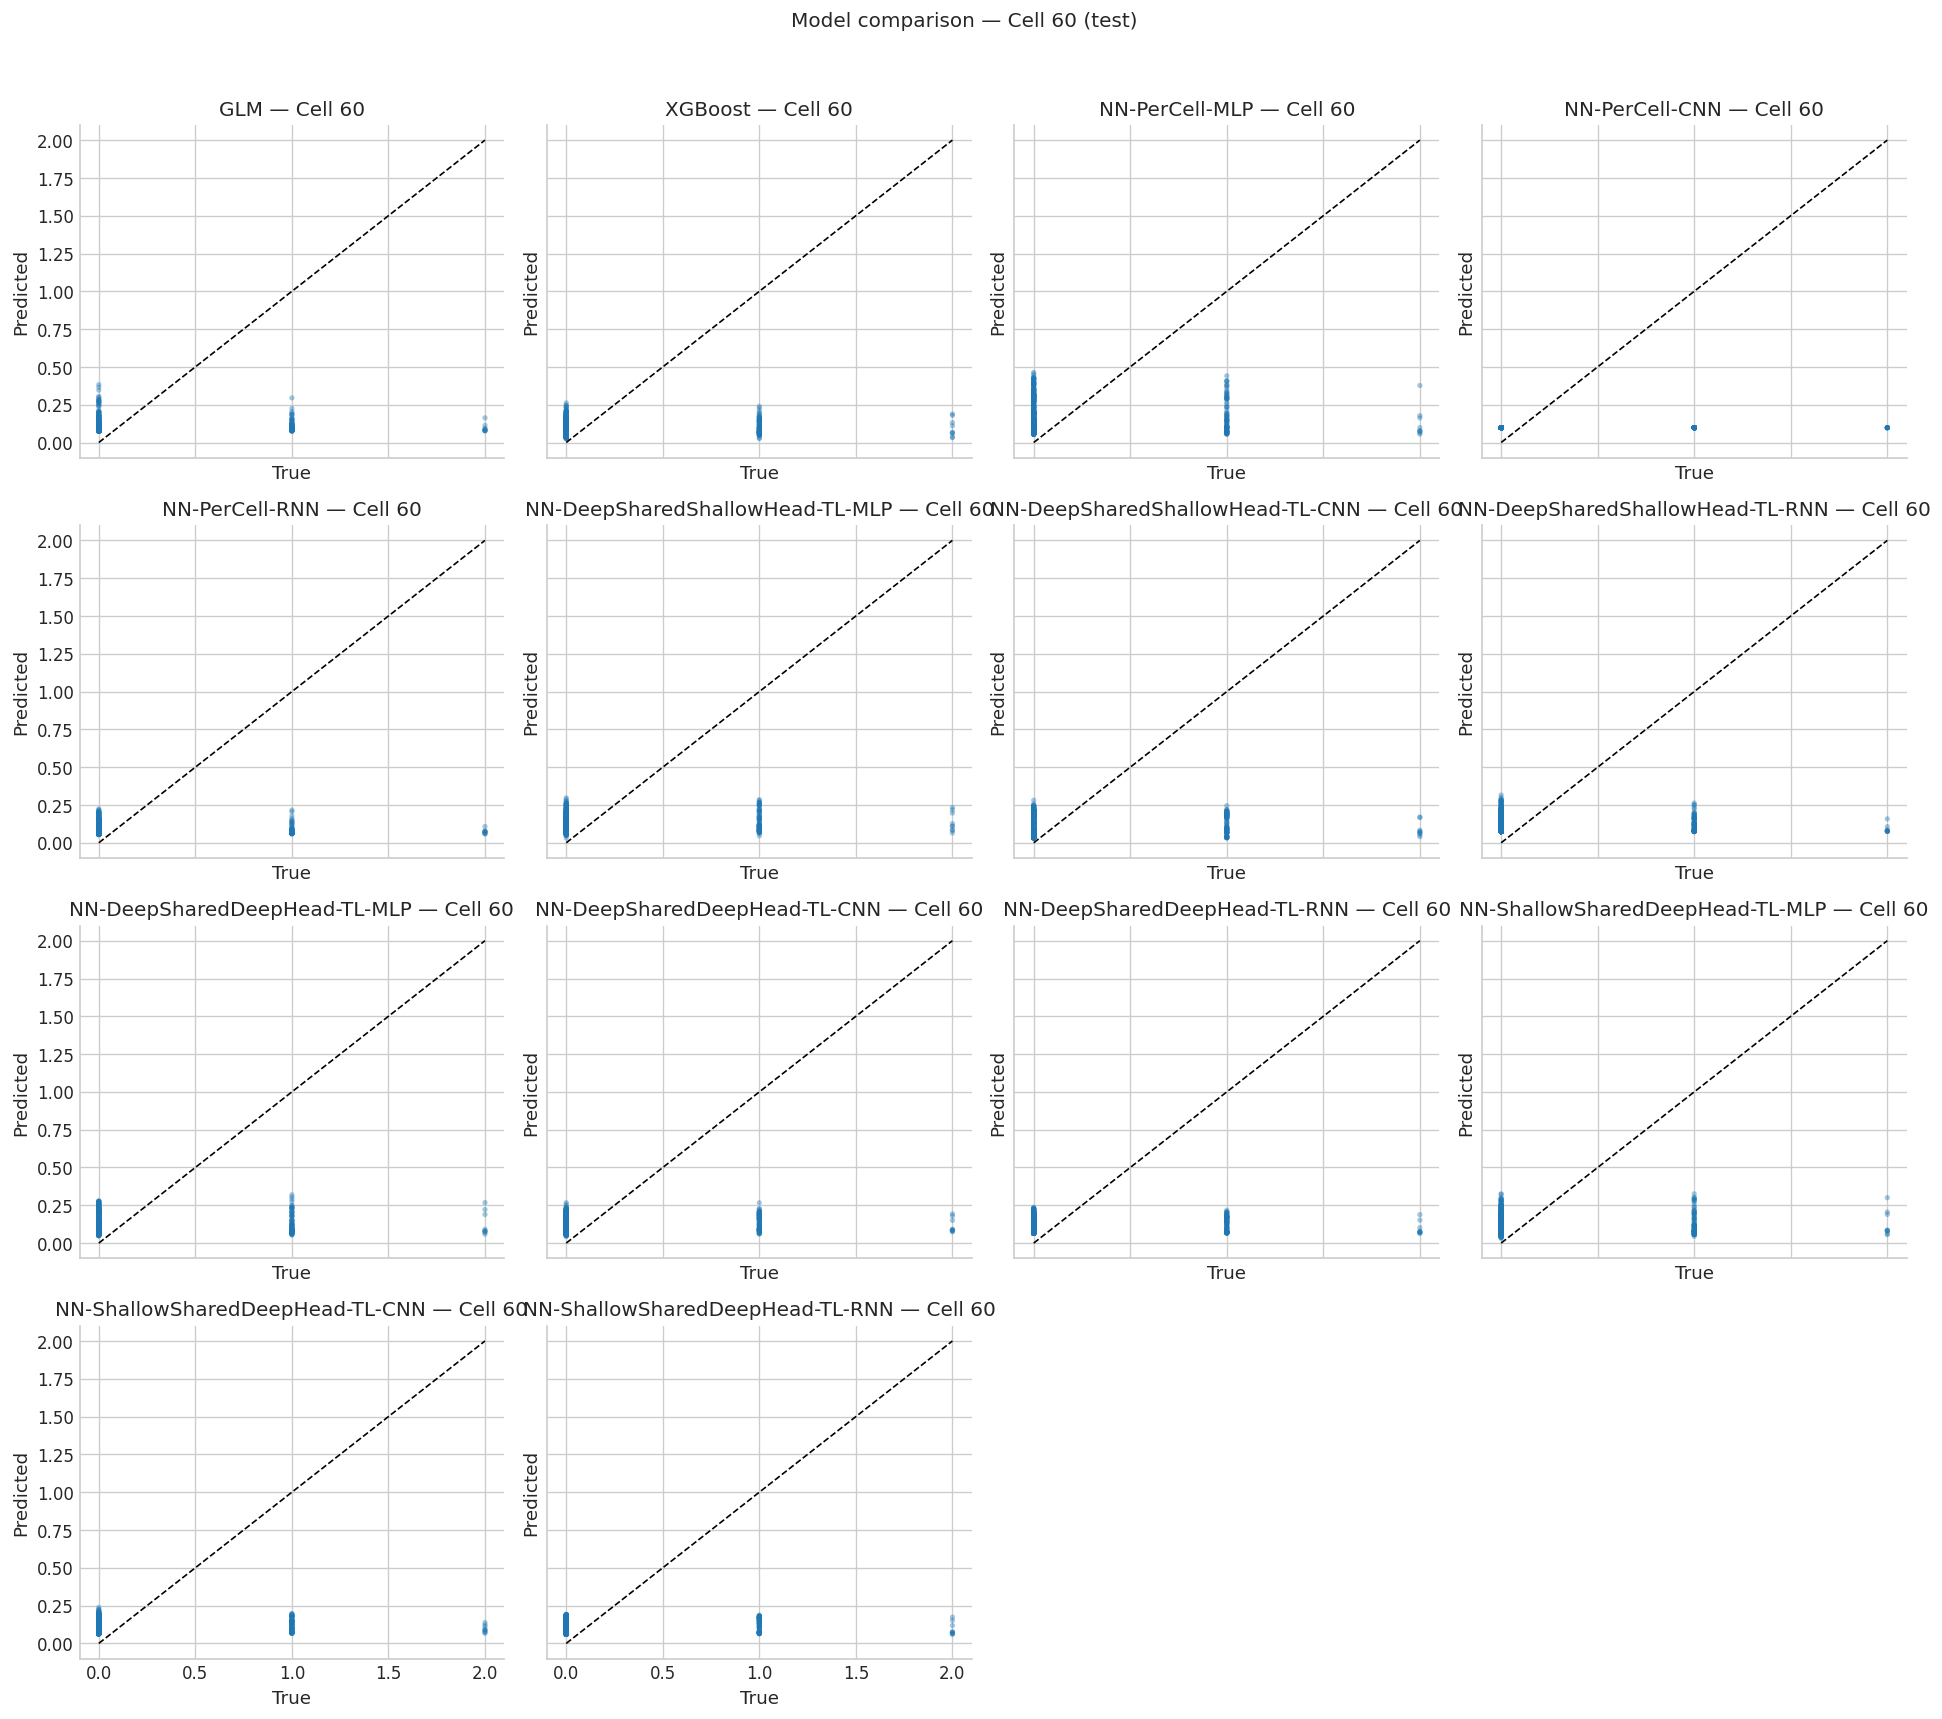

In [29]:
compare_models_for_cell(model_results_gs, cell=60, split="test")

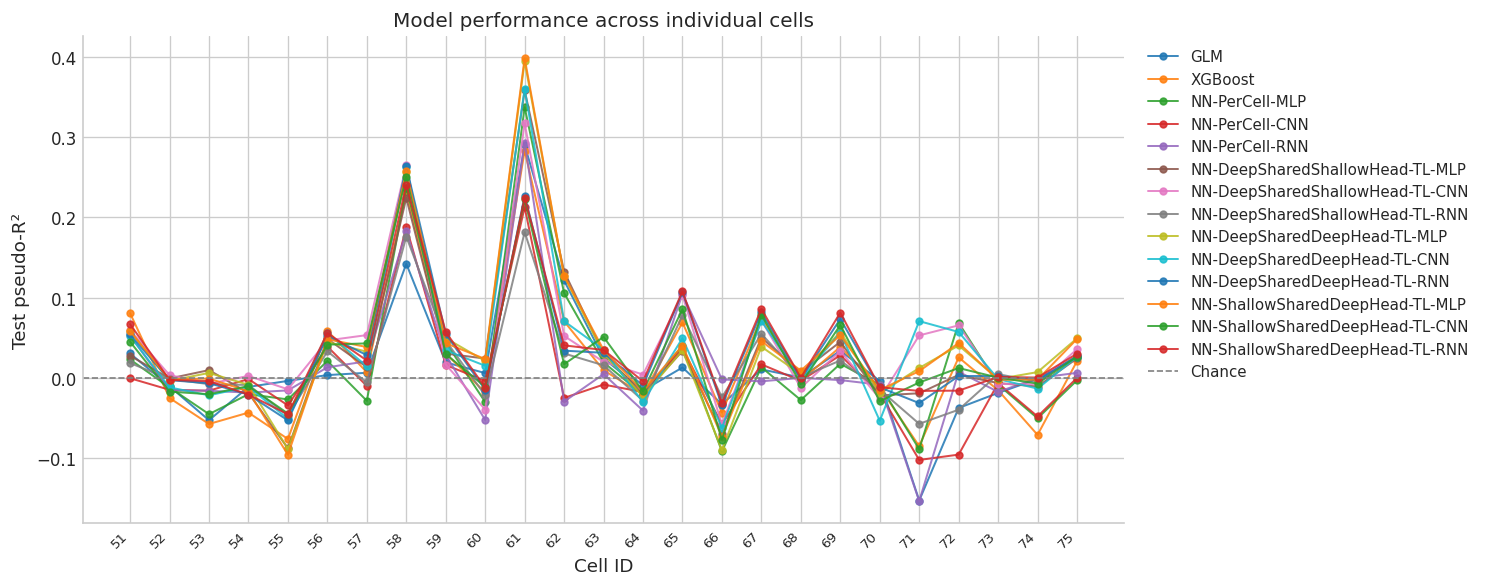

In [30]:
compare_r2_across_cells(model_results_gs, split="test")

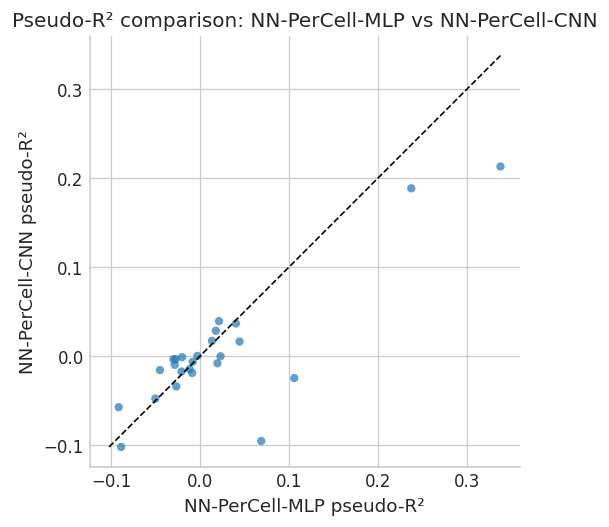

In [31]:
compare_models_pairwise_r2(
    model_results_gs,
    "NN-PerCell-MLP",
    "NN-PerCell-CNN",
)

In [32]:
# For journal_plot_pack, pass only the 4 key models for the summary outputs
# The full-model comparisons come from the dedicated figure cells above
key_models_for_pack = [
    (glm_results["results"], "GLM"),
    (xgboost_results["results"], "XGBoost"),
    (percell_results["MLP"]["GS"]["results"], "NN-PerCell-MLP"),
    (
        tl_results["deep_shared_deep_head"]["MLP"]["GS"]["results"],
        "NN-DeepSharedDeepHead-TL-MLP",
    ),
]

saved_paths = journal_plot_pack(
    key_models_for_pack,  # 4 models only
    cells=cells_gs,
    split="test",
    base_dir=BASE_RESULTS_DIR,
    pairwise_pairs=[
        ("GLM", "NN-PerCell-MLP"),
        ("GLM", "NN-DeepSharedDeepHead-TL-MLP"),
        ("NN-PerCell-MLP", "NN-DeepSharedDeepHead-TL-MLP"),
    ],
    example_cells=[60],
)
log_print(f"Generated {len(saved_paths)} plots")
for p in saved_paths[-5:]:
    log_print(f"  {p}")

Generated 7 plots
  ..\resources\results\real\batch_2\journal\r2_line.png
  ..\resources\results\real\batch_2\journal\pairwise_GLM_vs_NN-PerCell-MLP.png
  ..\resources\results\real\batch_2\journal\pairwise_GLM_vs_NN-DeepSharedDeepHead-TL-MLP.png
  ..\resources\results\real\batch_2\journal\pairwise_NN-PerCell-MLP_vs_NN-DeepSharedDeepHead-TL-MLP.png
  ..\resources\results\real\batch_2\journal\cell_60.png


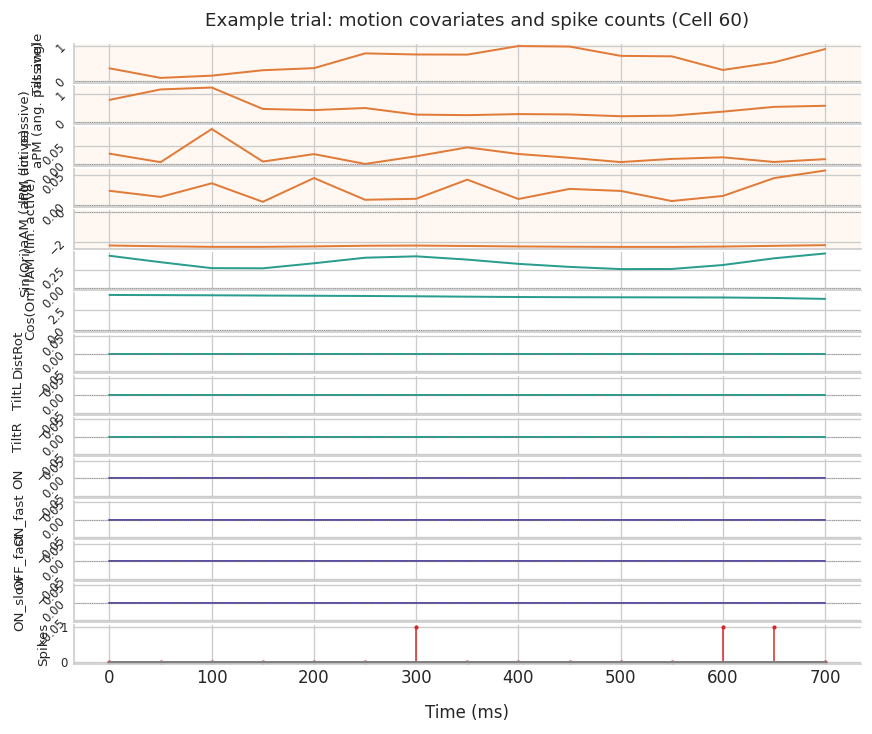

In [44]:
# Figure 1 panel: covariate time-series for one example trial
# Cell 6, trial 50 is a good choice — cell 6 has the highest pseudo-R²
# in batch 0 and trial 50 is well into the session where tilt events occur
fig_cov = plot_covariate_trial(
    X,
    Y,
    cell_ids,
    cell_idx=60,
    trial_idx=5,  # pick a mid-session tilt trial
    covariate_names=COVARIATE_NAMES_REAL,
    trials_per_cell=400,
    bin_duration_ms=50,
    # show_only_indices=[0, 1, 2, 3, 4],  # motion covariates only
    figsize=(8, 6),  # explicit size: compact and readable
    title="Example trial: motion covariates and spike counts (Cell 60)",
)

# Save at 300 DPI for print-quality output
from src.train.io import save_plot

# save_plot(fig_cov, "journal", "figure1_covariate_trial.png", base_dir=BASE_RESULTS_DIR)
# fig_cov.savefig(
#     f"{BASE_RESULTS_DIR}/journal/figure1_covariate_trial.pdf",
#     dpi=300,
#     bbox_inches="tight",
# )

fig_cov

In [35]:
# Figure 5: model comparison box plot for real data (batch 0)
fig_box = plot_r2_comparison_boxplot(
    model_results_gs,
    split="test",
    title=f"Batch 0 (cells 51-75): test pseudo-R² by model",
    rotate_labels=True,
)
save_plot(fig_box, "journal", "figure5_r2_boxplot.png", base_dir=BASE_RESULTS_DIR)

WindowsPath('../resources/results/real/batch_2/journal/figure5_r2_boxplot.png')

In [36]:
# Companion histogram — mirrors Figure 3E of Ebrahimi et al. (2025)
# Include only the key models for a clean comparison
key_models = [
    (glm_results["results"], "GLM"),
    (xgboost_results["results"], "XGBoost"),
    (percell_results["MLP"]["GS"]["results"], "NN-PerCell-MLP"),
    (
        tl_results["deep_shared_deep_head"]["MLP"]["GS"]["results"],
        "NN-DeepSharedDeepHead-TL-MLP",
    ),
]
fig_hist = plot_r2_histogram(
    key_models,
    split="test",
    title="Distribution of test pseudo-R² across cells (batch 2)",
)
save_plot(fig_hist, "journal", "figure5_r2_histogram.png", base_dir=BASE_RESULTS_DIR)

WindowsPath('../resources/results/real/batch_2/journal/figure5_r2_histogram.png')

In [37]:
# Exploratory: sort cells by GLM performance to see cross-model patterns
fig_line = compare_r2_across_cells(
    model_results_gs,
    split="test",
    sort_by="GLM",  # reorder cells from hardest to easiest for the GLM
)
save_plot(fig_line, "journal", "r2_sorted_by_glm.png", base_dir=BASE_RESULTS_DIR)

WindowsPath('../resources/results/real/batch_2/journal/r2_sorted_by_glm.png')